# Transformer example

This notebook builds a tiny **Transformer** whose attention is
constrained by a named edgelist: a token attends to another only
where the graph has an edge.

`kpnn2` does not ship a Transformer. You write the encoder,
feed-forward network (FFN), residual, pooling, and head in
PyTorch. `PackedMultiheadAttention` is the primitive it
contributes, scoring only
[live edgelist pairs](../concepts/#live-edge) — the pairs the graph
actually has. There is no `parse_attention()`; `parse_adjacency()`
already returns the [packed indices](../concepts/#packed-indices).

The same building block appears in prior-gated attention as in
[Milia et al., 2026](https://doi.org/10.48550/arXiv.2606.09558)
(DOI: [10.48550/arXiv.2606.09558](https://doi.org/10.48550/arXiv.2606.09558)).
We do **not** reproduce their dataset, metrics, or results. The
point here is generic: an edgelist becomes the allow-set of
attention.

It assumes you have already read [Feedforward
example](../feedforward-example/). That tutorial is a feedforward
`MaskedLinear` [knowledge-primed neural network](../concepts/#kpnn)
(KPNN). Here every node is a token and the prior is an attention
allow-set, not a [hop](../concepts/#hop) mask — a hop being everything
that arrives at one layer.

In [ ]:
import random

import numpy as np
import pandas as pd
import seaborn as sns
import torch
from graphviz import Digraph
from IPython.display import display
from matplotlib import pyplot as plt
from torch import nn

import kpnn2

In [ ]:
from matplotlib_inline.backend_inline import (
    set_matplotlib_formats,
)

random.seed(42)
np.random.seed(42)
torch.manual_seed(42)

set_matplotlib_formats(
    "svg",
    bbox_inches=None,
)
_FONT_SIZE = 14
_FIG_W = 7.0
_plot_rc = {
    "font.size": _FONT_SIZE,
    "axes.titlesize": _FONT_SIZE,
    "axes.labelsize": _FONT_SIZE,
    "xtick.labelsize": _FONT_SIZE,
    "ytick.labelsize": _FONT_SIZE,
    "legend.fontsize": _FONT_SIZE,
    "legend.title_fontsize": _FONT_SIZE,
    "lines.linewidth": 1.0,
    "font.family": "Liberation Sans",
    "text.color": "black",
    "axes.labelcolor": "black",
    "xtick.color": "black",
    "ytick.color": "black",
    "axes.edgecolor": "black",
    "axes.grid": False,
    "axes.facecolor": "none",
    "figure.facecolor": "none",
    "savefig.facecolor": "none",
    "savefig.edgecolor": "none",
    "svg.fonttype": "none",
}
plt.rcParams.update(_plot_rc)
sns.set_theme(
    style="ticks",
    rc=_plot_rc,
)


def _new_fig(height):
    return plt.figure(figsize=(_FIG_W, height))


def _style_ax(ax):
    ax.tick_params(labelsize=_FONT_SIZE)
    ax.title.set_fontsize(_FONT_SIZE)
    ax.xaxis.label.set_size(_FONT_SIZE)
    ax.yaxis.label.set_size(_FONT_SIZE)
    ax.set_facecolor("none")
    ax.grid(False)

## Define the graph

The prior is a small edgelist in which two nodes gather from
disjoint input sets:

- `input_signal_*` feed `node_a` (informative later)
- `input_noise_*` feed `node_b` (uninformative later)

The table has the same two columns as
[Feedforward example](../feedforward-example/): `source` and
`target`. In `kpnn2`, a row means **source feeds target**, and
attention keeps that direction: **query = target, key/value =
source**, so `node_a` attends to its signal inputs. That is the
same arrow as a KPNN linear layer.

A table written as query → key is the opposite column order.
Swap `source` and `target` before parsing if you want this
gathering convention.

Which [parser](../concepts/#parser) to call is a choice here: this graph
is a [directed acyclic graph](../concepts/#dag) (DAG), so
`parse_layered()` would accept it. Use `parse_adjacency()` anyway:
attention needs every node as one token in a single sequence, not split
by depth. Do not pass a hop mask to `PackedMultiheadAttention`.

In [ ]:
edgelist = pd.DataFrame(
    {
        "source": [
            "input_signal_1",
            "input_signal_2",
            "input_signal_3",
            "input_noise_1",
            "input_noise_2",
            "input_noise_3",
        ],
        "target": [
            "node_a",
            "node_a",
            "node_a",
            "node_b",
            "node_b",
            "node_b",
        ],
    }
)

spec = kpnn2.parse_adjacency(edgelist)
edgelist

,source,target
0,input_signal_1,node_a
1,input_signal_2,node_a
2,input_signal_3,node_a
3,input_noise_1,node_b
4,input_noise_2,node_b
5,input_noise_3,node_b


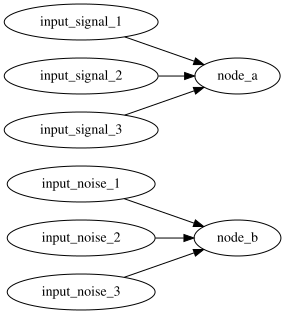

In [ ]:
dot = Digraph()
dot.attr(rankdir="LR")

with dot.subgraph() as s:
    s.attr(rank="same")
    for name in spec.input_nodes:
        s.node(name, name)

with dot.subgraph() as s:
    s.attr(rank="same")
    for name in spec.output_nodes:
        s.node(name, name)

for row in edgelist.itertuples(index=False):
    dot.edge(str(row.source), str(row.target))

dot

`parse_adjacency()` puts every node in one alphabetical sequence
and packs the live pairs. The roles are read off the graph:
measured features are in-degree 0 (`input_nodes`), gather nodes
are out-degree 0 (`output_nodes`). Both kinds are tokens. The
input role only says which columns `align_inputs()` indexes.

Two flags shape what the attention layer does here.
`add_self_loops=True`, set in the model below, ORs missing
`(i, i)` pairs into the layer, so isolated queries — the input
tokens, which have no incoming edges — are not forced to zero.
`need_weights=True` returns packed per-edge weights along
`source_index` / `target_index`, not the dense `(L, S)` map
of `nn.MultiheadAttention`, so
you can plot edge thickness on the prior graph without a full
attention matrix.

In [ ]:
n_nodes = len(spec.nodes)
spec.nodes, spec.input_nodes, spec.output_nodes

(('input_noise_1',
  'input_noise_2',
  'input_noise_3',
  'input_signal_1',
  'input_signal_2',
  'input_signal_3',
  'node_a',
  'node_b'),
 ('input_noise_1',
  'input_noise_2',
  'input_noise_3',
  'input_signal_1',
  'input_signal_2',
  'input_signal_3'),
 ('node_a', 'node_b'))

## Write a Transformer around PackedMultiheadAttention

Everything around the attention layer is yours to write: a feature
projection, a learned identity embedding per named node, packed
attention with layer normalization before it (Pre-LN), a token-wise
FFN, and residuals. The
classification head reads only the gather tokens
(`spec.output_index`).

One shape mismatch must be handled on the way in. The named
input table still goes through `align_inputs()`, whose index is
`len(input_nodes)` long, not `n_nodes` long, so `forward` scatters
those columns into a zeroed token sequence with `spec.input_index`
before attention. Train and test share that index here because
both tables use the same column order. Gather-node positions stay
zero: they are not measured features; they collect input values
through the prior.

In [ ]:
class TokenEncoder(nn.Module):
    def __init__(
        self,
        spec: kpnn2.AdjacencySpec,
        embed_dim: int,
        num_heads: int,
    ):
        super().__init__()
        self.spec = spec
        n_nodes = len(spec.nodes)
        self.expr_proj = nn.Linear(
            1,
            embed_dim,
        )
        self.id_embed = nn.Embedding(
            n_nodes,
            embed_dim,
        )
        self.attn = kpnn2.PackedMultiheadAttention(
            spec.source_index,
            spec.target_index,
            n_nodes,
            n_nodes,
            embed_dim,
            num_heads,
            add_self_loops=True,
        )
        self.norm1 = nn.LayerNorm(embed_dim)
        self.ffn = nn.Sequential(
            nn.Linear(
                embed_dim,
                2 * embed_dim,
            ),
            nn.ReLU(),
            nn.Linear(
                2 * embed_dim,
                embed_dim,
            ),
        )
        self.norm2 = nn.LayerNorm(embed_dim)

    def forward(self, x):
        n_nodes = len(self.spec.nodes)
        tokens = self.expr_proj(x.unsqueeze(-1))
        node_ids = torch.arange(
            n_nodes,
            device=x.device,
        )
        tokens = tokens + self.id_embed(node_ids)
        normed = self.norm1(tokens)
        attended, _ = self.attn(
            normed,
            normed,
            normed,
        )
        tokens = tokens + attended
        tokens = tokens + self.ffn(self.norm2(tokens))
        return tokens


class PriorTransformer(nn.Module):
    def __init__(
        self,
        spec: kpnn2.AdjacencySpec,
        embed_dim: int = 8,
        num_heads: int = 2,
    ):
        super().__init__()
        self.spec = spec
        self.encoder = TokenEncoder(
            spec,
            embed_dim,
            num_heads,
        )
        n_out = len(spec.output_index)
        self.head = nn.Linear(
            n_out * embed_dim,
            1,
        )

    def forward(self, x_inputs):
        n_nodes = len(self.spec.nodes)
        state = x_inputs.new_zeros(
            x_inputs.shape[0],
            n_nodes,
        )
        state[:, self.spec.input_index] = x_inputs
        encoded = self.encoder(state)
        node_tokens = encoded[:, self.spec.output_index]
        pooled = node_tokens.reshape(
            node_tokens.shape[0],
            -1,
        )
        return self.head(pooled)

In [ ]:
model = PriorTransformer(spec)
(
    n_nodes,
    model.encoder.attn.nnz,
    spec.source_index,
    spec.target_index,
)

(8, 14, (0, 1, 2, 3, 4, 5), (7, 7, 7, 6, 6, 6))

## Simulate data, align features, and train

Same binary toy pattern as
[Feedforward example](../feedforward-example/): `input_signal_*`
change mean between classes, `input_noise_*` do not. 100 samples
per class for training, 50 for testing.


In [ ]:
informative_features = [
    "input_signal_1",
    "input_signal_2",
    "input_signal_3",
]
noise_features = [
    "input_noise_1",
    "input_noise_2",
    "input_noise_3",
]
all_features = informative_features + noise_features

n_train_per_class = 100
n_test_per_class = 50
rng = np.random.default_rng(42)


def simulate_binary_classification_data(n_per_class, rng):
    x0_signal = rng.normal(
        loc=0.0,
        scale=1.0,
        size=(n_per_class, len(informative_features)),
    )
    x1_signal = rng.normal(
        loc=2.0,
        scale=1.0,
        size=(n_per_class, len(informative_features)),
    )
    x0_noise = rng.normal(
        loc=0.0,
        scale=1.0,
        size=(n_per_class, len(noise_features)),
    )
    x1_noise = rng.normal(
        loc=0.0,
        scale=1.0,
        size=(n_per_class, len(noise_features)),
    )
    x0 = np.concatenate([x0_signal, x0_noise], axis=1)
    x1 = np.concatenate([x1_signal, x1_noise], axis=1)
    x = np.concatenate([x0, x1], axis=0)
    y = np.concatenate(
        [
            np.zeros(n_per_class, dtype=int),
            np.ones(n_per_class, dtype=int),
        ]
    )
    permutation = rng.permutation(len(y))
    x = x[permutation]
    y = y[permutation]
    x_df = pd.DataFrame(x, columns=all_features)
    y_series = pd.Series(y, name="label")
    return x_df, y_series


x_train_df, y_train = simulate_binary_classification_data(
    n_per_class=n_train_per_class,
    rng=rng,
)
x_test_df, y_test = simulate_binary_classification_data(
    n_per_class=n_test_per_class,
    rng=rng,
)

# Train and test share column order, so one col is valid.
col = kpnn2.align_inputs(x_train_df.columns, spec)
x_train = torch.as_tensor(
    x_train_df.to_numpy()[:, col],
    dtype=torch.float32,
)
x_test = torch.as_tensor(
    x_test_df.to_numpy()[:, col],
    dtype=torch.float32,
)
display(x_train_df.head())
x_train.shape, x_test.shape, len(spec.nodes)

,input_signal_1,input_signal_2,input_signal_3,input_noise_1,input_noise_2,input_noise_3
0,-0.695943,-0.223859,0.242497,-1.139429,-0.481241,1.437777
1,3.068472,2.232878,2.234401,-0.712102,1.370541,-0.484030
2,-0.471525,0.263717,0.052467,0.288917,1.244947,-0.431339
3,0.941464,1.874991,3.481456,-0.109727,-0.035611,-1.364742
4,-0.926576,-0.389810,-1.376686,-1.119536,0.447814,0.058274


(torch.Size([200, 6]), torch.Size([100, 6]), 8)

Loss before first update: 0.6977
Loss after final update:  0.1122
Test accuracy: 0.92


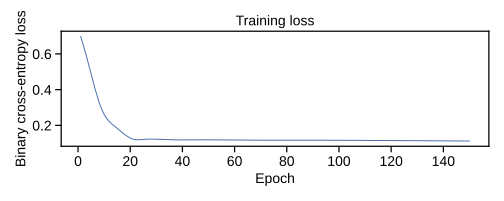

In [ ]:
y_train_tensor = torch.tensor(
    y_train.values.reshape(-1, 1),
    dtype=torch.float32,
)

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=1e-2,
    weight_decay=1e-2,
)
loss_fn = nn.BCEWithLogitsLoss()

n_epochs = 150
loss_history = []
model.train()
for _ in range(n_epochs):
    optimizer.zero_grad()
    logits = model(x_train)
    loss = loss_fn(logits, y_train_tensor)
    loss.backward()
    optimizer.step()
    loss_history.append(loss.item())

model.eval()
with torch.no_grad():
    pred = (torch.sigmoid(model(x_test))[:, 0] > 0.5).float()
    y_test_tensor = torch.tensor(
        y_test.values,
        dtype=torch.float32,
    )
    test_acc = float((pred == y_test_tensor).float().mean())

print(
    "Loss before first update:",
    round(loss_history[0], 4),
)
print(
    "Loss after final update: ",
    round(loss_history[-1], 4),
)
print("Test accuracy:", round(test_acc, 3))

_new_fig(2.8)
plt.plot(
    range(1, n_epochs + 1),
    loss_history,
    linewidth=1,
)
plt.xlabel("Epoch")
plt.ylabel("Binary cross-entropy loss")
plt.title("Training loss")
plt.tight_layout()
plt.show()

## Interpret named nodes

Attribution runs at two levels, input features and named nodes.
`kpnn2` does not wrap Captum; it only supplies the names. Feature
scores use `IntegratedGradients` on the tensor you build by
applying the `align_inputs()` index (or on a pre-ordered tensor
that skipped that call). Node scores use `LayerConductance` on the
encoder, whose output is `(batch, n_nodes, embed_dim)`; summing
the embed axis leaves a width of `spec.nodes`, which
`map_node_attributions()` then labels (no `layer=`: this is an
`AdjacencySpec`). See
[Mapping attributions](../map-node-attributions/).

Read the node table with one expectation. Input tokens are
not read by the head, so encoder conductance on those positions is
zero. The gather tokens should not be: `node_a` collects the
informative inputs.

In [ ]:
from captum.attr import (
    IntegratedGradients,
    LayerConductance,
)

model.eval()
ig = IntegratedGradients(model)
feature_tensor = ig.attribute(
    x_test,
    target=0,
)
feature_attr = pd.DataFrame(
    feature_tensor.detach().cpu().numpy(),
    columns=spec.input_nodes,
)
feature_summary = (
    feature_attr.abs()
    .mean()
    .rename("mean_abs_attribution")
    .sort_values(ascending=False)
    .to_frame()
)
feature_summary

,mean_abs_attribution
input_signal_3,3.036363
input_signal_1,1.632126
input_signal_2,1.467716
input_noise_2,0.050085
input_noise_1,0.047762
input_noise_3,0.035458


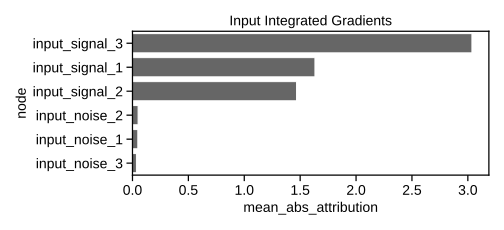

In [ ]:
_new_fig(3.2)
ax = sns.barplot(
    data=feature_summary.reset_index().rename(columns={"index": "node"}),
    x="mean_abs_attribution",
    y="node",
    color="0.4",
)
_style_ax(ax)
ax.set_title("Input Integrated Gradients")
plt.tight_layout()
plt.show()

In [ ]:
conductor = LayerConductance(
    model,
    model.encoder,
)
token_attr = conductor.attribute(
    x_test,
    target=0,
)
node_scores = token_attr.detach().abs().sum(dim=-1)
node_attr = kpnn2.map_node_attributions(
    attributions=node_scores,
    spec=spec,
)
node_summary = (
    node_attr.to_pandas()
    .mean()
    .rename("mean_abs_attribution")
    .sort_values(ascending=False)
    .to_frame()
)
node_summary

,mean_abs_attribution
node,
node_a,5.501345
node_b,0.256008
input_noise_1,0.000000
input_noise_2,0.000000
input_signal_1,0.000000
input_noise_3,0.000000
input_signal_3,0.000000
input_signal_2,0.000000


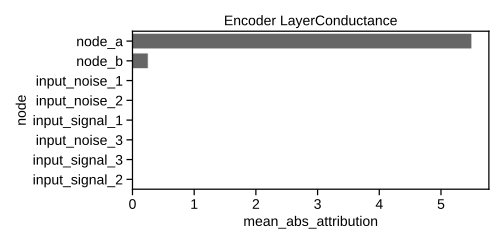

In [ ]:
_new_fig(3.4)
ax = sns.barplot(
    data=node_summary.reset_index(),
    x="mean_abs_attribution",
    y="node",
    color="0.4",
)
_style_ax(ax)
ax.set_title("Encoder LayerConductance")
plt.tight_layout()
plt.show()

## Control: rewire the prior

Keep the same samples and labels. Point the signal inputs at
`node_b` and the noise inputs at `node_a`. If the named graph is
the inductive bias, `node_b` should now carry the task.


In [ ]:
rewired = pd.DataFrame(
    {
        "source": [
            "input_signal_1",
            "input_signal_2",
            "input_signal_3",
            "input_noise_1",
            "input_noise_2",
            "input_noise_3",
        ],
        "target": [
            "node_b",
            "node_b",
            "node_b",
            "node_a",
            "node_a",
            "node_a",
        ],
    }
)
rewired_spec = kpnn2.parse_adjacency(rewired)
torch.manual_seed(42)
rewired_model = PriorTransformer(rewired_spec)

optimizer = torch.optim.Adam(
    rewired_model.parameters(),
    lr=1e-2,
    weight_decay=1e-2,
)
rewired_model.train()
for _ in range(n_epochs):
    optimizer.zero_grad()
    logits = rewired_model(x_train)
    loss = loss_fn(logits, y_train_tensor)
    loss.backward()
    optimizer.step()

rewired_model.eval()
rewired_scores = (
    LayerConductance(
        rewired_model,
        rewired_model.encoder,
    )
    .attribute(
        x_test,
        target=0,
    )
    .detach()
    .abs()
    .sum(dim=-1)
)
rewired_summary = (
    kpnn2.map_node_attributions(
        attributions=rewired_scores,
        spec=rewired_spec,
    )
    .to_pandas()
    .mean()
    .rename("rewired")
)
compare = pd.concat(
    [
        node_summary["mean_abs_attribution"].rename("original"),
        rewired_summary,
    ],
    axis=1,
).loc[["node_a", "node_b"]]
compare

,original,rewired
node,,
node_a,5.501345,0.588434
node_b,0.256008,4.813755


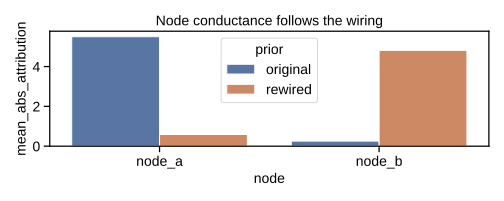

In [ ]:
plot_df = compare.reset_index().melt(
    id_vars="node",
    var_name="prior",
    value_name="mean_abs_attribution",
)
_new_fig(2.8)
ax = sns.barplot(
    data=plot_df,
    x="node",
    y="mean_abs_attribution",
    hue="prior",
)
_style_ax(ax)
ax.set_title("Node conductance follows the wiring")
plt.tight_layout()
plt.show()

## What this page leaves out

Milia et al. train on a large atlas with extra machinery
(variable-length tokens, sparse host batching, sinusoidal
encodings, attention-map metrics). None of that is in `kpnn2`,
and none of it is repeated here.

Two of them have a defined place elsewhere. `key_padding_mask`
is the analogue of "this input is absent in this sample": a
boolean mask over keys, applied in packed space. Host-sparse
storage (for example AnnData `.X`) stays in the caller's loop;
tensors that enter the module are dense.

`PackedLinear` is a different primitive (one scalar per edge, not
attention). See [PackedLinear](../packed_linear/) when the
adjacency square would hurt RAM, and the
[Cyclic graph example](../cyclic-graph-example/) for a cyclic
`MaskedLinear` state update.

This tutorial graph is tiny, so the default
`chunk_size=None` (all live pairs at once) is fine. On a large
adjacency graph, a positive `chunk_size` softmaxes and mixes in
slices of that many edges so training does not save
`(batch, nnz, heads, head_dim)` pair gathers. The API page is
[PackedMultiheadAttention](../reference/PackedMultiheadAttention/).